# Saved-model evaluation

In [4]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import RocCurveDisplay

from url_phishing_classification.config import OPERATING_THRESHOLD
from url_phishing_classification.evaluation import (
    evaluate_probabilities,
    overlap_summary,
    preprocess_for_evaluation,
)

In [5]:
pd.set_option("display.max_columns", None)

TRAIN_PATH = Path("../data/train_preprocessed.csv")
TEST_PATH = Path("../data/test.csv")
EXTERNAL_TEST_PATH = Path("../data/external_test.csv")
MODEL_PATH = Path("../models/all_engineered_model.joblib")
URL_COLUMN = "url"
TARGET = "label"

## Load training reference data and the finalized model

In [6]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

model = joblib.load(MODEL_PATH)
if not hasattr(model, "feature_names_in_"):
    raise TypeError("The saved model does not expose feature_names_in_.")

model_features = list(model.feature_names_in_)
train_preprocessed = pd.read_csv(TRAIN_PATH)
missing_train_features = sorted(set(model_features) - set(train_preprocessed.columns))
if missing_train_features:
    raise KeyError(f"Training reference is missing model features: {missing_train_features}")

print(f"Model: {MODEL_PATH.name}")
print(f"Expected features: {len(model_features)}")
print(f"Operating threshold: {OPERATING_THRESHOLD:.2f}")

Model: all_engineered_model.joblib
Expected features: 44
Operating threshold: 0.95


## Read and preprocess the two test dataframes


In [7]:
test_df = pd.read_csv(TEST_PATH)
external_test_df = pd.read_csv(EXTERNAL_TEST_PATH)

test_preprocessed, test_raw_rows = preprocess_for_evaluation(test_df)
external_test_preprocessed, external_test_raw_rows = preprocess_for_evaluation(external_test_df)

processed_tests = {
    "test": test_preprocessed,
    "external_test": external_test_preprocessed,
}
preprocessing_summary = pd.DataFrame(
    [
        {
            "dataset": "test",
            "raw_rows": test_raw_rows,
            "rows_after_deduplication": len(test_preprocessed),
            "rows_removed": test_raw_rows - len(test_preprocessed),
        },
        {
            "dataset": "external_test",
            "raw_rows": external_test_raw_rows,
            "rows_after_deduplication": len(external_test_preprocessed),
            "rows_removed": external_test_raw_rows - len(external_test_preprocessed),
        },
    ]
)
preprocessing_summary

,dataset,raw_rows,rows_after_deduplication,rows_removed
0,test,2858,2834,24
1,external_test,2858,2858,0


## Training-set overlap audit

In [8]:
overlap_results = pd.concat(
    [
        overlap_summary(train_preprocessed, test_frame).assign(dataset=dataset)
        for dataset, test_frame in processed_tests.items()
    ],
    ignore_index=True,
)
overlap_results[
    [
        "dataset",
        "overlap_key",
        "train_unique_values",
        "test_unique_values",
        "shared_unique_values",
        "test_unique_overlap_rate",
        "test_rows_with_train_match",
        "test_row_overlap_rate",
    ]
].round(4)

,dataset,overlap_key,train_unique_values,test_unique_values,shared_unique_values,test_unique_overlap_rate,test_rows_with_train_match,test_row_overlap_rate
0,test,normalized_url,8325,2834,138,0.0487,138,0.0487
1,test,hostname_path,8127,2795,93,0.0333,128,0.0452
2,test,hostname,6273,2399,499,0.2080,899,0.3172
3,test,registered_domain,5072,2024,559,0.2762,1329,0.4689
4,test,domain,5084,2028,571,0.2816,1349,0.4760
5,test,subdomain,1805,718,189,0.2632,1677,0.5917
6,test,suffix,303,193,154,0.7979,2776,0.9795
7,test,path,5266,1844,207,0.1123,1033,0.3645
8,test,query,1003,358,57,0.1592,68,0.0240
9,external_test,normalized_url,8325,2858,0,0.0000,0,0.0000


## Evaluate the finalized model on both test dataframes

Eval both test datasets on 0.5 and 0.95 thresholds.

In [9]:
evaluation_thresholds = (0.50, OPERATING_THRESHOLD)
evaluation_records, predicted_probabilities = [], {}
for dataset, test_frame in processed_tests.items():
    if TARGET not in test_frame:
        raise KeyError(f"{dataset} has no {TARGET!r} column, so metrics cannot be calculated.")
    missing_features = sorted(set(model_features) - set(test_frame.columns))
    if missing_features:
        raise KeyError(f"{dataset} is missing model features: {missing_features}")

    probabilities = model.predict_proba(test_frame.loc[:, model_features])[:, 1]
    predicted_probabilities[dataset] = probabilities
    for threshold in evaluation_thresholds:
        evaluation_records.append(
            {"dataset": dataset, "rows": len(test_frame)}
            | evaluate_probabilities(test_frame[TARGET].astype(int), probabilities, threshold)
        )

evaluation_results = pd.DataFrame(evaluation_records)
evaluation_results.round(3)

,dataset,rows,threshold,accuracy,recall,precision,false_positive_rate,false_negative_rate,roc_auc,true_negatives,false_positives,false_negatives,true_positives
0,test,2834,0.50,0.824,0.784,0.850,0.136,0.216,0.906,1234,195,303,1102
1,test,2834,0.95,0.669,0.340,0.978,0.008,0.660,0.906,1418,11,927,478
2,external_test,2858,0.50,0.782,0.571,0.987,0.008,0.429,0.894,1418,11,613,816
3,external_test,2858,0.95,0.628,0.257,1.000,0.000,0.743,0.894,1429,0,1062,367


Threshold: 0.5

- Precision and recall on the test dataset is close to the performance measured on the training set
- On the external dataset recall drops significantly, probably due to it containing phishing URLs that are very different from the ones in the training set

Threshold: 0.95

- Again,  Precision and recall on the test are very close to training set measurements
- Recall is lower again significantly on the external test set compared to training, and suprisingly precisions is 1.0

## Visual comparison


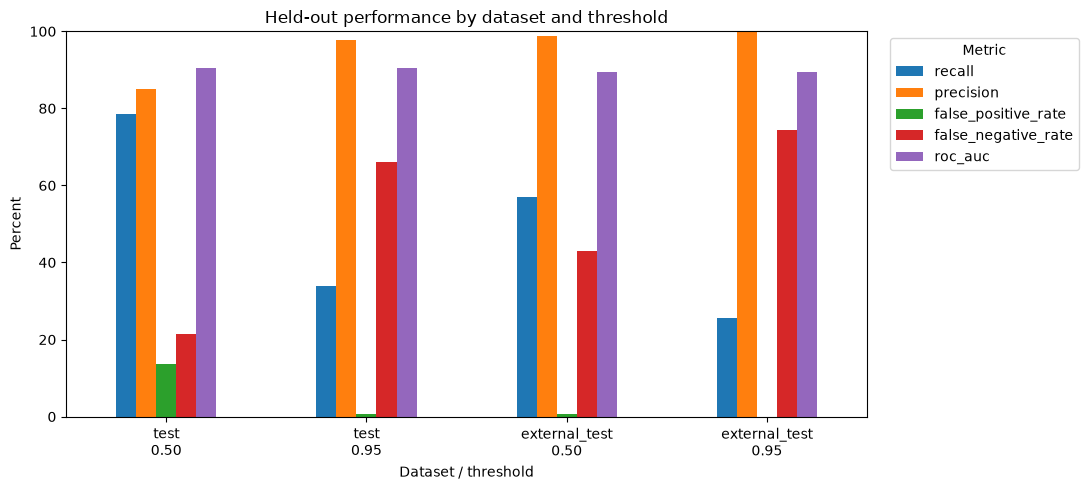

In [14]:
metric_columns = ["recall", "precision", "false_positive_rate", "false_negative_rate", "roc_auc"]
plot_labels = [f"{row.dataset}\n{row.threshold:.2f}" for row in evaluation_results.itertuples()]
plot_data = evaluation_results[metric_columns].mul(100).set_axis(plot_labels)
ax = plot_data.plot.bar(figsize=(11, 5), rot=0)
ax.set(
    title="Held-out performance by dataset and threshold",
    ylabel="Percent",
    xlabel="Dataset / threshold",
    ylim=(0, 100),
)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

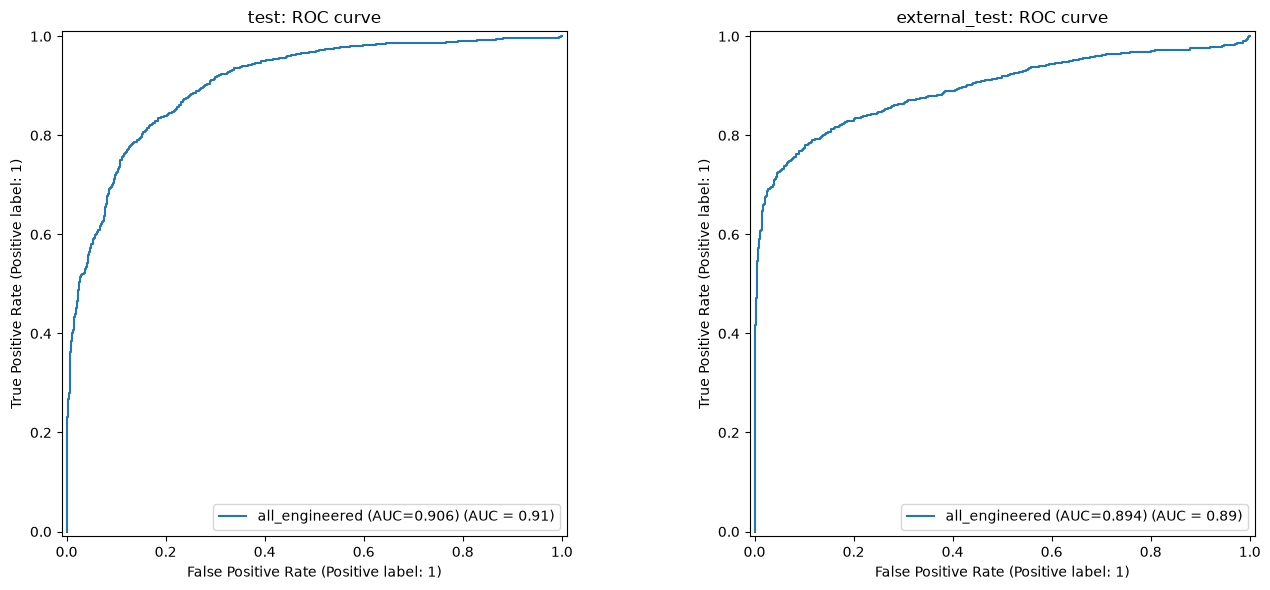

In [15]:
fig, axes = plt.subplots(1, len(processed_tests), figsize=(7 * len(processed_tests), 6), squeeze=False)
for ax, (dataset, test_frame) in zip(axes.flat, processed_tests.items(), strict=True):
    probabilities = predicted_probabilities[dataset]
    auc = evaluation_results.loc[evaluation_results["dataset"] == dataset, "roc_auc"].iloc[0]
    RocCurveDisplay.from_predictions(
        test_frame[TARGET].astype(int),
        probabilities,
        name=f"all_engineered (AUC={auc:.3f})",
        ax=ax,
    )
    ax.set_title(f"{dataset}: ROC curve")
plt.tight_layout()

## Deployment threshold trade-offs

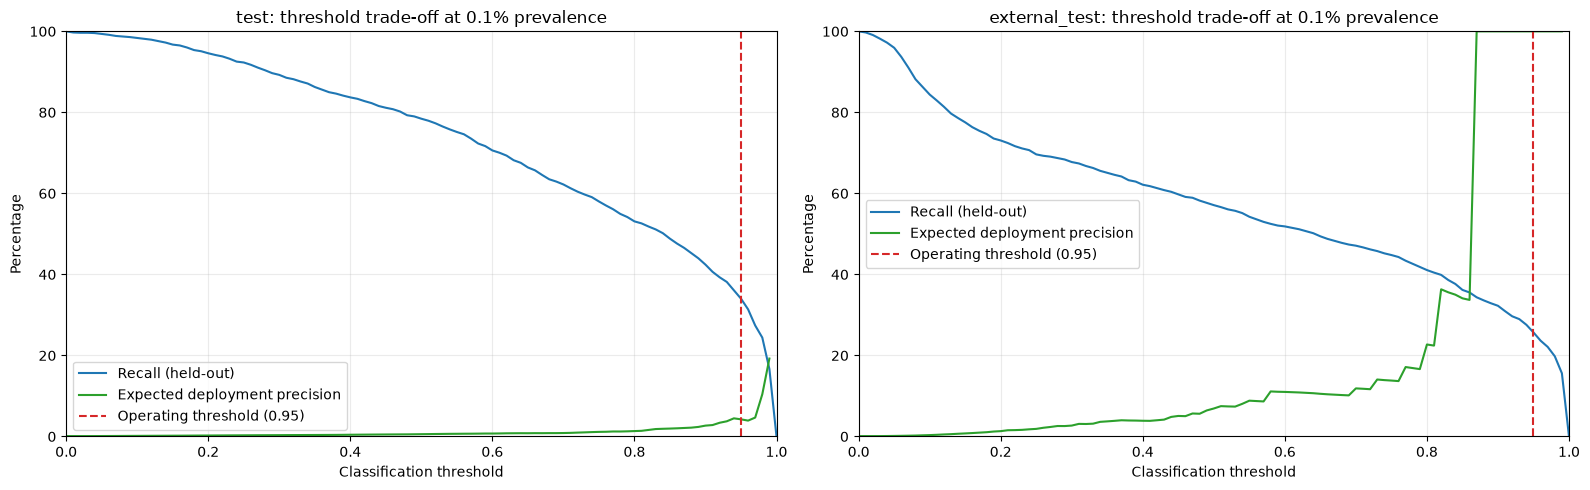

In [ ]:
deployment_prevalence = 0.001
threshold_grid = np.linspace(0.0, 1.0, 101)
deployment_threshold_results = {}

for dataset, test_frame in processed_tests.items():
    y_true = test_frame[TARGET].astype(int)
    results = pd.DataFrame(
        [evaluate_probabilities(y_true, predicted_probabilities[dataset], threshold) for threshold in threshold_grid]
    ).rename(columns={"false_positive_rate": "fpr"})
    denominator = results["recall"] * deployment_prevalence + results["fpr"] * (1 - deployment_prevalence)
    results["deployment_precision"] = np.divide(
        results["recall"] * deployment_prevalence,
        denominator,
        out=np.full(len(results), np.nan),
        where=denominator > 0,
    )
    deployment_threshold_results[dataset] = results

fig, axes = plt.subplots(1, len(processed_tests), figsize=(8 * len(processed_tests), 5), squeeze=False)
for ax, (dataset, results) in zip(axes.flat, deployment_threshold_results.items(), strict=True):
    ax.plot(results["threshold"], results["recall"] * 100, label="Recall (held-out)")
    ax.plot(
        results["threshold"],
        results["deployment_precision"] * 100,
        color="tab:green",
        label="Expected deployment precision",
    )
    ax.axvline(
        OPERATING_THRESHOLD, color="tab:red", linestyle="--", label=f"Operating threshold ({OPERATING_THRESHOLD:.2f})"
    )
    ax.set(
        title=f"{dataset}: threshold trade-off at 0.1% prevalence",
        xlabel="Classification threshold",
        ylabel="Percentage",
        xlim=(0, 1),
        ylim=(0, 100),
    )
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()

### Representative thresholds

In [13]:
n_urls = 100_000
expected_phishing = n_urls * deployment_prevalence
expected_legitimate = n_urls * (1 - deployment_prevalence)
representative_thresholds = sorted({0.50, 0.80, 0.90, OPERATING_THRESHOLD, 0.98})
threshold_tables = []

for dataset, test_frame in processed_tests.items():
    y_true = test_frame[TARGET].astype(int)
    table = pd.DataFrame(
        [
            evaluate_probabilities(y_true, predicted_probabilities[dataset], threshold)
            for threshold in representative_thresholds
        ]
    ).rename(columns={"false_positive_rate": "fpr"})
    denominator = table["recall"] * deployment_prevalence + table["fpr"] * (1 - deployment_prevalence)
    table["expected_deployment_precision"] = np.divide(
        table["recall"] * deployment_prevalence,
        denominator,
        out=np.full(len(table), np.nan),
        where=denominator > 0,
    )
    table["true_phishing_urls_caught_per_100000"] = expected_phishing * table["recall"]
    table["legitimate_urls_falsely_flagged_per_100000"] = expected_legitimate * table["fpr"]
    threshold_tables.append(table.assign(dataset=dataset))

deployment_threshold_table = pd.concat(threshold_tables, ignore_index=True)
deployment_threshold_table[
    [
        "dataset",
        "threshold",
        "recall",
        "fpr",
        "expected_deployment_precision",
        "true_phishing_urls_caught_per_100000",
        "legitimate_urls_falsely_flagged_per_100000",
    ]
].round(4)

,dataset,threshold,recall,fpr,expected_deployment_precision,true_phishing_urls_caught_per_100000,legitimate_urls_falsely_flagged_per_100000
0,test,0.50,0.7843,0.1365,0.0057,78.4342,13632.2603
1,test,0.80,0.5310,0.0392,0.0134,53.0961,3914.9055
2,test,0.90,0.4242,0.0154,0.0268,42.4199,1537.9986
3,test,0.95,0.3402,0.0077,0.0424,34.0214,768.9993
4,test,0.98,0.2441,0.0021,0.1043,24.4128,209.7271
5,external_test,0.50,0.5710,0.0077,0.0691,57.1029,768.9993
6,external_test,0.80,0.4108,0.0014,0.2271,41.0777,139.8181
7,external_test,0.90,0.3226,0.0000,1.0000,32.2603,0.0000
8,external_test,0.95,0.2568,0.0000,1.0000,25.6823,0.0000
9,external_test,0.98,0.1980,0.0000,1.0000,19.8041,0.0000
